# Held-Out T Cell Analysis (CL:0000084)

**Setup**: Human → Mouse transport via CellOT (10K iters) with SCGen encoder (5K iters).
T cells held out as OOD test set. Training on all other matched cell types.

**Results path**: `cellot/cellot_gpu/results/speciesot_cpu/`

In [6]:
import sys
sys.path.insert(0, "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
from pathlib import Path
from scipy.spatial.distance import cdist

RESULTS = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results/speciesot_cpu")
CELLOT_DIR = RESULTS / "speciesot_cellot"
SCGEN_DIR = RESULTS / "speciesot_scgen"

print("SCGen status:", (SCGEN_DIR / "cache/status").read_text().strip())
print("CellOT status:", (CELLOT_DIR / "cache/status").read_text().strip())

SCGen status: done
CellOT status: done


## 1. Load Training Scalars (SCGen + CellOT Loss Curves)

In [7]:
import pickle
import h5py

def load_scalars(cache_dir):
    """Load CellOT/SCGen training scalars from HDF5 (pandas PyTables format)."""
    path = cache_dir / "cache" / "scalars"
    out = {}
    with h5py.File(path, "r") as f:
        grp = "train" if "train" in f else list(f.keys())[0]
        t = f[grp]["table"]
        arr = t[:]
        steps = np.asarray(arr["index"])
        vals = np.asarray(arr["values_block_0"])
        kind = t.attrs.get("values_block_0_kind", b"")
        try:
            names = pickle.loads(kind) if kind else []
        except Exception:
            names = [f"col_{i}" for i in range(vals.shape[1] if vals.ndim > 1 else 1)]
        if vals.ndim == 1:
            vals = vals.reshape(-1, 1)
        for i, name in enumerate(names):
            if i < vals.shape[1]:
                out[name] = vals[:, i]
        out["step"] = steps
    return out

scgen_scalars = load_scalars(SCGEN_DIR)
cellot_scalars = load_scalars(CELLOT_DIR)

print("SCGen scalar keys:", list(scgen_scalars.keys())[:10])
print("CellOT scalar keys:", list(cellot_scalars.keys())[:10])

SCGen scalar keys: ['loss', 'mse', 'reg', 'step']
CellOT scalar keys: ['gloss', 'floss', 'step']


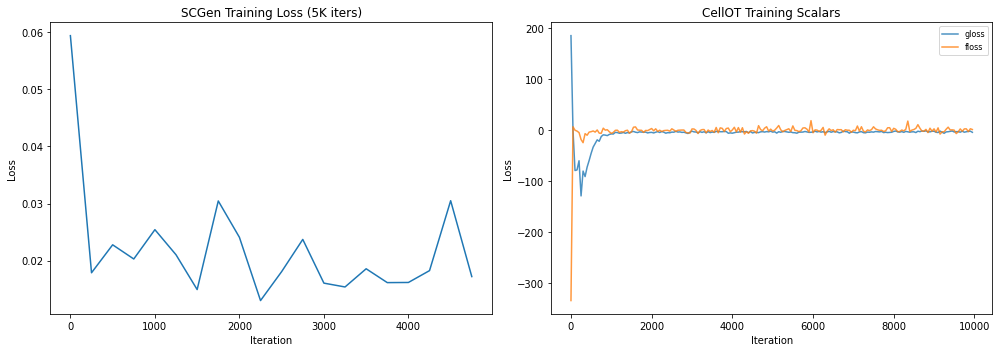

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SCGen loss
x = scgen_scalars.get('step', np.arange(len(scgen_scalars.get('loss', []))))
if 'loss' in scgen_scalars:
    ax = axes[0]
    losses = scgen_scalars['loss']
    if isinstance(losses, dict):
        for k, v in losses.items():
            ax.plot(x[:len(v)], v, label=k, alpha=0.8)
        ax.legend()
    else:
        ax.plot(x[:len(losses)], losses)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title("SCGen Training Loss (5K iters)")
else:
    for k, v in scgen_scalars.items():
        if k != 'step' and ('loss' in k.lower() or 'mse' in k.lower()):
            axes[0].plot(x[:len(v)], v, label=k, alpha=0.8)
    axes[0].legend(fontsize=8)
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("SCGen Training Scalars")

# CellOT loss
x_c = cellot_scalars.get('step', np.arange(len(cellot_scalars.get('gloss', cellot_scalars.get('loss', [])))))
if 'loss' in cellot_scalars:
    ax = axes[1]
    losses = cellot_scalars['loss']
    if isinstance(losses, dict):
        for k, v in losses.items():
            ax.plot(x_c[:len(v)], v, label=k, alpha=0.8)
        ax.legend()
    else:
        ax.plot(x_c[:len(losses)], losses)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title("CellOT Training Loss (10K iters)")
else:
    for k, v in cellot_scalars.items():
        if k != 'step' and ('loss' in k.lower() or 'obj' in k.lower()):
            axes[1].plot(x_c[:len(v)], v, label=k, alpha=0.8)
    axes[1].legend(fontsize=8)
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("CellOT Training Scalars")

plt.tight_layout()
plt.savefig("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/analysis/speciesot_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# The SCGen converges incredibly fast, a concern is that we are using little data to train a relatively huge model
# Think about adding more data for training

# Suspicion of overfitting, so try to use more dataset


## 2. Load Imputed (Predicted) vs Actual Mouse T Cells

In [ ]:
imputed_latent = anndata.read_h5ad(CELLOT_DIR / "evals_ood_latent_space" / "imputed.h5ad")
imputed_data = anndata.read_h5ad(CELLOT_DIR / "evals_ood_data_space" / "imputed.h5ad")

print("Imputed (latent space):", imputed_latent.shape)
print("Imputed (data space):", imputed_data.shape)

# Load the full dataset to get actual treated (mouse) T cells
full_data = anndata.read_h5ad(
    "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse/hvg-top1k.h5ad"
)
print("\nFull dataset:", full_data.shape)

# The OOD mouse T cells = actual ground truth
mouse_tcells = full_data[
    (full_data.obs['condition'].astype(str).str.strip() == 'mouse') &
    (full_data.obs['cell_type_ontology_term_id'].astype(str).str.strip() == 'CL:0000084')
]
human_tcells = full_data[
    (full_data.obs['condition'].astype(str).str.strip() == 'human') &
    (full_data.obs['cell_type_ontology_term_id'].astype(str).str.strip() == 'CL:0000084')
]
print(f"\nMouse T cells (ground truth): {mouse_tcells.n_obs}")
print(f"Human T cells (source):       {human_tcells.n_obs}")
print(f"Imputed cells (predictions):  {imputed_data.n_obs}")
# This part is reversed

Imputed (latent space): (52, 50)
Imputed (data space): (52, 1000)

Full dataset: (12836, 1000)

Mouse T cells (ground truth): 102
Human T cells (source):       102
Imputed cells (predictions):  52


## 3. Distribution Metrics (computed on all available OOD cells)

In [10]:
from scipy.sparse import issparse

def to_dense_df(adata):
    X = adata.X
    if issparse(X):
        X = X.toarray()
    return pd.DataFrame(X, index=adata.obs_names, columns=adata.var_names if hasattr(adata, 'var_names') and len(adata.var_names) > 0 else range(X.shape[1]))

imputed_df = to_dense_df(imputed_data)

# Match treated cells: use the same obs_names if possible, otherwise use all mouse T cells
# The evaluation script uses the OOD split (half of T cells).
# imputed_df has the predicted mouse T cells. We need the actual mouse T cells with matching indices.
mouse_tcell_df = to_dense_df(mouse_tcells)

# The imputed cells correspond to transported human T cells. 
# The "treated" ground truth is the OOD mouse T cells.
# Since toggle_ood takes half, we may need to match by count.
n_imputed = len(imputed_df)
n_treated = len(mouse_tcell_df)
print(f"Imputed (predicted): {n_imputed} cells x {imputed_df.shape[1]} features")
print(f"Treated (actual mouse T): {n_treated} cells x {mouse_tcell_df.shape[1]} features")

# Use min of both for fair comparison
n_eval = min(n_imputed, n_treated)
imputed_sample = imputed_df.iloc[:n_eval]
treated_sample = mouse_tcell_df.iloc[:n_eval]

# Align columns
common_cols = imputed_sample.columns.intersection(treated_sample.columns)
if len(common_cols) == 0:
    imputed_sample.columns = [str(c) for c in range(imputed_sample.shape[1])]
    treated_sample.columns = [str(c) for c in range(treated_sample.shape[1])]
    common_cols = imputed_sample.columns
imputed_sample = imputed_sample[common_cols]
treated_sample = treated_sample[common_cols]

print(f"Evaluating on {n_eval} cells x {len(common_cols)} features")

Imputed (predicted): 52 cells x 1000 features
Treated (actual mouse T): 102 cells x 1000 features
Evaluating on 52 cells x 1000 features


In [11]:
from sklearn.neighbors import NearestNeighbors

def compute_metrics(treated, imputed):
    """Compute all evaluation metrics between treated (ground truth) and imputed (predicted)."""
    mut, mui = treated.mean(0), imputed.mean(0)
    stdt, stdi = treated.std(0), imputed.std(0)

    metrics = {}
    metrics['r2_means'] = pd.Series.corr(mut, mui)
    metrics['r2_stds'] = pd.Series.corr(stdt, stdi)
    metrics['l2_means'] = np.linalg.norm(mut - mui)
    metrics['l2_stds'] = np.linalg.norm(stdt - stdi)

    # Pairwise feature correlations
    pwct = treated.corr().values[np.triu_indices(treated.shape[1], k=1)]
    pwci = imputed.corr().values[np.triu_indices(imputed.shape[1], k=1)]
    metrics['r2_pairwise_feat_corrs'] = np.corrcoef(pwct, pwci)[0, 1]
    metrics['l2_pairwise_feat_corrs'] = np.linalg.norm(pwct - pwci)

    # MMD
    from cellot.losses.mmd import mmd_distance
    gammas = np.logspace(1, -3, num=50)
    mmd_vals = [mmd_distance(treated, imputed, g) for g in gammas]
    metrics['mmd'] = np.mean(mmd_vals)

    # KNN enrichment
    n = min(len(treated), len(imputed))
    combined = pd.concat([imputed.iloc[:n], treated.iloc[:n]], axis=0)
    labels = np.array(['imputed'] * n + ['treated'] * n)
    k_max = min(100, n - 1)
    if k_max > 1:
        nn = NearestNeighbors(n_neighbors=k_max + 1).fit(combined)
        _, indices = nn.kneighbors(combined)
        indices = indices[:, 1:]  # drop self
        neighbor_labels = labels[indices]
        same_label = (neighbor_labels == labels[:, None])
        if k_max >= 50:
            metrics['enrichment_k50'] = same_label[:, :50].mean()
        metrics[f'enrichment_k{k_max}'] = same_label[:, :k_max].mean()

    return metrics

metrics = compute_metrics(treated_sample, imputed_sample)

print("=" * 60)
print("EVALUATION METRICS  (Data Space, OOD T Cells)")
print("=" * 60)
for k, v in metrics.items():
    print(f"  {k:35s} = {v:.4f}")
print("=" * 60)
print(f"\n  r2_means close to 1.0 = good (mean gene expression matches)")
print(f"  mmd close to 0.0 = good (distributions overlap)")
print(f"  enrichment close to 0.5 = good (perfect mixing of predicted & real)")

EVALUATION METRICS  (Data Space, OOD T Cells)
  r2_means                            = 0.0649
  r2_stds                             = 0.0720
  l2_means                            = 0.5673
  l2_stds                             = 3.8137
  r2_pairwise_feat_corrs              = nan
  l2_pairwise_feat_corrs              = nan
  mmd                                 = 0.1027
  enrichment_k50                      = 0.7352
  enrichment_k51                      = 0.7223

  r2_means close to 1.0 = good (mean gene expression matches)
  mmd close to 0.0 = good (distributions overlap)
  enrichment close to 0.5 = good (perfect mixing of predicted & real)


## 4. Mean Gene Expression: Predicted vs Actual Mouse T Cells

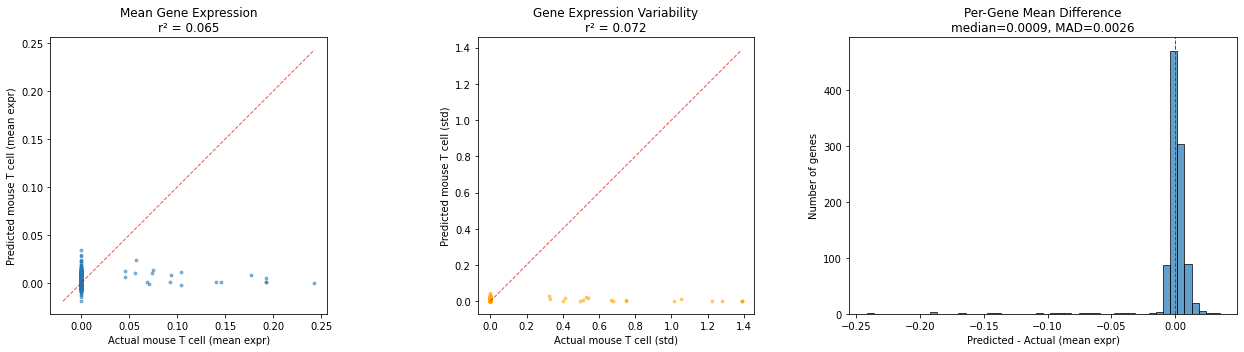

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mut = treated_sample.mean(0)
mui = imputed_sample.mean(0)
stdt = treated_sample.std(0)
stdi = imputed_sample.std(0)

# Mean expression scatter
ax = axes[0]
ax.scatter(mut, mui, s=8, alpha=0.5)
lims = [min(mut.min(), mui.min()), max(mut.max(), mui.max())]
ax.plot(lims, lims, 'r--', lw=1, alpha=0.7)
ax.set_xlabel("Actual mouse T cell (mean expr)")
ax.set_ylabel("Predicted mouse T cell (mean expr)")
ax.set_title(f"Mean Gene Expression\nr² = {metrics['r2_means']:.3f}")
ax.set_aspect('equal')

# Std scatter
ax = axes[1]
ax.scatter(stdt, stdi, s=8, alpha=0.5, color='orange')
lims = [min(stdt.min(), stdi.min()), max(stdt.max(), stdi.max())]
ax.plot(lims, lims, 'r--', lw=1, alpha=0.7)
ax.set_xlabel("Actual mouse T cell (std)")
ax.set_ylabel("Predicted mouse T cell (std)")
ax.set_title(f"Gene Expression Variability\nr² = {metrics['r2_stds']:.3f}")
ax.set_aspect('equal')

# Distribution of per-gene differences
ax = axes[2]
diff = (mui - mut)
ax.hist(diff, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', lw=1)
ax.set_xlabel("Predicted - Actual (mean expr)")
ax.set_ylabel("Number of genes")
ax.set_title(f"Per-Gene Mean Difference\nmedian={diff.median():.4f}, MAD={diff.abs().median():.4f}")

plt.tight_layout()
plt.savefig("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/analysis/speciesot_tcell_gene_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. UMAP: Human T Cells (source) vs Predicted vs Actual Mouse T Cells

/n/home01/jzhou1125/.conda/envs/CellOT/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


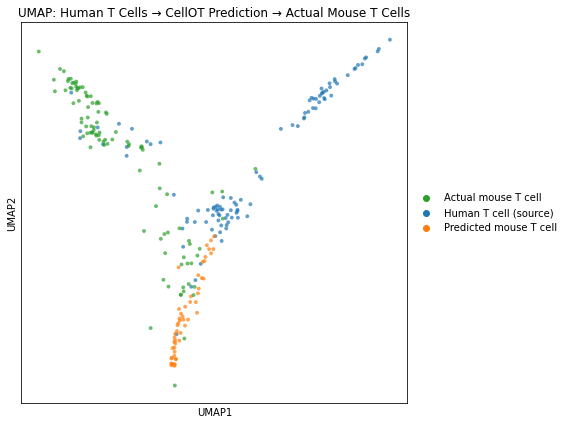

In [13]:
human_tcell_df = to_dense_df(human_tcells)

# Build a combined AnnData for UMAP: source (human), predicted (imputed), actual (mouse)
n_imp = len(imputed_df)
n_mouse = len(mouse_tcell_df)
n_human = len(human_tcell_df)

# Align all to same feature space
if imputed_df.shape[1] == mouse_tcell_df.shape[1] == human_tcell_df.shape[1]:
    combined_X = np.vstack([
        human_tcell_df.values[:min(n_human, 102)],
        imputed_df.values[:min(n_imp, 102)],
        mouse_tcell_df.values[:min(n_mouse, 102)],
    ])
    labels = (
        ['Human T cell (source)'] * min(n_human, 102) +
        ['Predicted mouse T cell'] * min(n_imp, 102) +
        ['Actual mouse T cell'] * min(n_mouse, 102)
    )
else:
    # Data space imputed may have different dims; use data space
    n = min(n_imp, n_mouse, n_human)
    combined_X = np.vstack([
        human_tcell_df.values[:n],
        imputed_df.values[:n],
        mouse_tcell_df.values[:n],
    ])
    labels = ['Human T cell (source)'] * n + ['Predicted mouse T cell'] * n + ['Actual mouse T cell'] * n

umap_adata = anndata.AnnData(X=combined_X)
umap_adata.obs['group'] = pd.Categorical(labels)

sc.pp.pca(umap_adata, n_comps=min(30, combined_X.shape[1] - 1))
sc.pp.neighbors(umap_adata)
sc.tl.umap(umap_adata)

fig, ax = plt.subplots(figsize=(8, 6))
sc.pl.umap(umap_adata, color='group', ax=ax, show=False,
           palette={'Human T cell (source)': '#1f77b4',
                    'Predicted mouse T cell': '#ff7f0e',
                    'Actual mouse T cell': '#2ca02c'},
           size=60, alpha=0.7)
ax.set_title("UMAP: Human T Cells → CellOT Prediction → Actual Mouse T Cells")
plt.tight_layout()
plt.savefig("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/analysis/speciesot_tcell_umap.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Metrics Summary Table

In [14]:
summary = pd.DataFrame([
    {"Metric": k, "Value": f"{v:.4f}", "Interpretation": interp}
    for k, v, interp in [
        ("r2_means", metrics['r2_means'], "1.0 = perfect mean match"),
        ("r2_stds", metrics['r2_stds'], "1.0 = perfect variability match"),
        ("l2_means", metrics['l2_means'], "0.0 = perfect (lower is better)"),
        ("l2_stds", metrics['l2_stds'], "0.0 = perfect (lower is better)"),
        ("r2_pairwise_feat_corrs", metrics['r2_pairwise_feat_corrs'], "1.0 = gene-gene correlations preserved"),
        ("mmd", metrics['mmd'], "0.0 = distributions identical"),
    ] + [
        (k, v, "0.5 = perfect mixing") for k, v in metrics.items() if 'enrichment' in k
    ]
])

print("=" * 70)
print("  SPECIESOT: Held-Out T Cell (CL:0000084) Evaluation Summary")
print(f"  Model: CellOT (10K iters) + SCGen encoder (5K iters)")
print(f"  OOD cells: {n_eval} T cells, 1000 HVGs")
print("=" * 70)
display(summary)

print("\nKey takeaways:")
r2m = metrics['r2_means']
mmd_val = metrics['mmd']
if r2m > 0.9:
    print(f"  - r2_means={r2m:.3f}: Strong agreement in mean gene expression")
elif r2m > 0.7:
    print(f"  - r2_means={r2m:.3f}: Moderate agreement in mean gene expression")
else:
    print(f"  - r2_means={r2m:.3f}: Weak agreement -- model may need more iterations or data")

enrich_keys = [k for k in metrics if 'enrichment' in k]
if enrich_keys:
    enrich_val = metrics[enrich_keys[0]]
    if abs(enrich_val - 0.5) < 0.1:
        print(f"  - enrichment={enrich_val:.3f}: Good mixing (predicted ~ actual)")
    elif enrich_val > 0.6:
        print(f"  - enrichment={enrich_val:.3f}: Predicted cells cluster with themselves (poor mixing)")
    else:
        print(f"  - enrichment={enrich_val:.3f}: Predicted cells over-integrate with actual")

  SPECIESOT: Held-Out T Cell (CL:0000084) Evaluation Summary
  Model: CellOT (10K iters) + SCGen encoder (5K iters)
  OOD cells: 52 T cells, 1000 HVGs


,Metric,Value,Interpretation
0,r2_means,0.0649,1.0 = perfect mean match
1,r2_stds,0.0720,1.0 = perfect variability match
2,l2_means,0.5673,0.0 = perfect (lower is better)
3,l2_stds,3.8137,0.0 = perfect (lower is better)
4,r2_pairwise_feat_corrs,nan,1.0 = gene-gene correlations preserved
5,mmd,0.1027,0.0 = distributions identical
6,enrichment_k50,0.7352,0.5 = perfect mixing
7,enrichment_k51,0.7223,0.5 = perfect mixing



Key takeaways:
  - r2_means=0.065: Weak agreement -- model may need more iterations or data
  - enrichment=0.735: Predicted cells cluster with themselves (poor mixing)
